# Non-Linear Optimization: Multivariable Functions
In this exercise, the goal is to minimize the function

$$
f(x, y) = e^{-x^2 - y^2} \sin(x) \cos(y),
$$
which combines exponential decay with sinusoidal variations. This makes it a compelling case for gradient descent optimization.
Unlike typical loss functions used in machine learning, where minimization is performed with respect to model parameters and data, here the aim is directly to find the values of $x$ and $y$ that minimize $f(x, y)$. In this context, $f(x, y)$ serves as a measure of error when evaluated with respect to the model parameters. Besides $x$ and $y$ are not treated as model parameters but simply as variables within the mathematical function.
## Steps
The following steps will be needed
- Compute partial derivatives to calculate the gradient in a point.
- Calculating forward (prediction) and backward (gradient steps) passes of the function.
- Iteratively using the forward and backward passes to optimize the function.


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#forward">Task 1: Forward pass</a>
            </li>
            <li>
            <a href="#testing">Task 2: Explain the function</a>
            </li>
            <li>
            <a href="#partial">Task 3: Backward pass pen and paper</a>
            </li>
            <li>
            <a href="#partial1">Task 4: Backward implementation</a>
            </li>
            <li>
            <a href="#partial2">Task 5: Gradient descent</a>
            </li>
            <li>
            <a href="#plotting">Task 6: Optimization path</a>
            </li>
            <li>
            <a href="#reflection">Task 7: Reflection</a>
            </li>
        </ul>
    </div>
</article>

## Class Implementation
The function $f(x, y)$ and its gradient descent optimization will be implemented within the `ExpTrig`
 class defined in the cell below
The class includes the following methods, which must be implemented in the subsequent tasks.
1. `forward`
  must return the function value of `f(x,y)`
 e.g., the predictions
2. `df_dx`
  must return the partial derivative of the function with respect to `x`

3. `df_dy`
 must return the partial derivative of the function with respect to `y`

4. `backward`
 must return the gradient of `f(x,y)`
 as a tuple `(df_dx, df_dy)`
. The naming 'backward' is used due to its reference to backpropagation.
5. `display_function`
 makes a figure of the function defined in `forward`
.



In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from math import e, sin, cos

class ExpTrig:

    def forward(self, x, y):
        """
        Args:
        x: x-values (Can be single float or 1D array)
        y: y-values (Can be single float or 1D array)

        Returns:
        The function values of f (size-like x and y)
        """
        # Fixed: should be cos(y) not cos(x) based on title
        return np.exp(-x**2 - y**2) * np.sin(x) * np.cos(y)

    def df_dx(self, x, y):
        """
        Args:
        x: x-values (Can be single float or 1D numpy array)
        y: y-values (Can be single float or 1D numpy array)

        Returns:
        The partial derivative of f with respect to x (size-like x and y)
        """
        # f(x,y) = e^(-x²-y²) * sin(x) * cos(y)
        # Using product rule: d/dx[u*v*w] = u'vw + uv'w + uvw'
        # where u = e^(-x²-y²), v = sin(x), w = cos(y)
        
        # d/dx[e^(-x²-y²)] = e^(-x²-y²) * (-2x)
        # d/dx[sin(x)] = cos(x)
        # d/dx[cos(y)] = 0 (y is constant w.r.t. x)
        
        exp_term = np.exp(-x**2 - y**2)
        sin_x = np.sin(x)
        cos_y = np.cos(y)
        
        # Product rule: u'vw + uv'w + uvw'
        # = (-2x)*exp*sin*cos + exp*cos(x)*cos + exp*sin*0
        # = exp*cos(y) * [(-2x)*sin(x) + cos(x)]
        return exp_term * cos_y * (-2*x * sin_x + np.cos(x))

    def df_dy(self, x, y):
        """
        Args:
        x: x-values (Can be single float or 1D numpy array)
        y: y-values (Can be single float or 1D numpy array)

        Returns:
        The partial derivative of f with respect to y (size-like x and y)
        """
        # f(x,y) = e^(-x²-y²) * sin(x) * cos(y)
        # Using product rule
        
        # d/dy[e^(-x²-y²)] = e^(-x²-y²) * (-2y)
        # d/dy[sin(x)] = 0 (x is constant w.r.t. y)
        # d/dy[cos(y)] = -sin(y)
        
        exp_term = np.exp(-x**2 - y**2)
        sin_x = np.sin(x)
        cos_y = np.cos(y)
        
        # Product rule: u'vw + uv'w + uvw'
        # = (-2y)*exp*sin*cos + exp*0*cos + exp*sin*(-sin(y))
        # = exp*sin(x) * [(-2y)*cos(y) - sin(y)]
        return exp_term * sin_x * (-2*y * cos_y - np.sin(y))

    def backward(self, x, y):
        """
        args:
        x: x-values
        y: y-values
        Returns:
        Partial derivatives of the function (i.e. the gradient) as a tuple
        """
        return (self.df_dx(x, y), self.df_dy(x, y))

    def display_function(self):
        x = np.linspace(-2, 2, 400)
        y = np.linspace(-2, 2, 400)
        x_grid, y_grid = np.meshgrid(x, y)
        x_flat = x_grid.flatten()
        y_flat = y_grid.flatten()

        z = self.forward(x_flat, y_flat)
        z_grid = z.reshape(x_grid.shape)

        # Create a 3D plot  
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(x_grid, y_grid, z_grid, cmap='viridis', alpha=0.8)
        ax.set_xlabel('X axis')
        ax.set_ylabel('Y axis')
        ax.set_zlabel('f(x, y)')
        ax.set_title('Surface of f(x, y) = e^{-x^2 - y^2} sin(x) cos(y)')
        plt.show()


---
**Task 1 (easy): Forward pass👩‍💻**
1. Implement the  `forward`
 function in the class.
2. Run the cell below to visualize the function. 


---

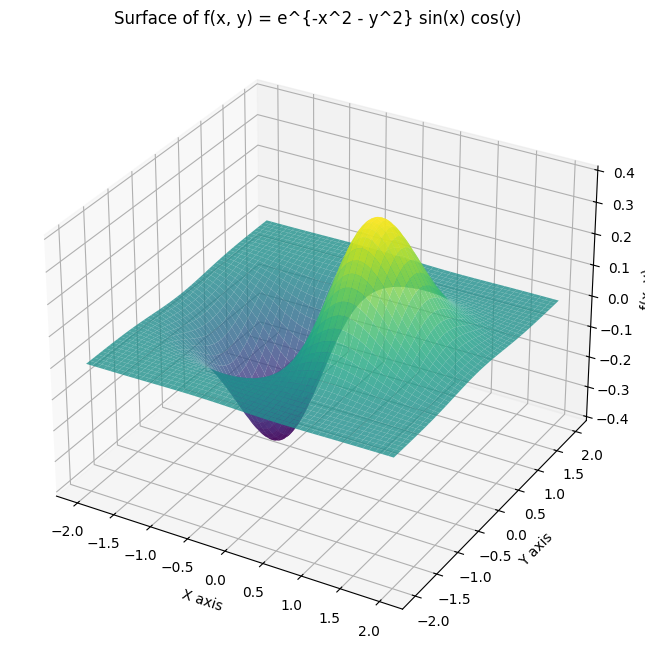

In [14]:
# Grid of x, y points
f = ExpTrig()

f.display_function()


---
**Task 2 (easy): Explain the function💡**
Use the plot to identify the minima of the function and discuss potential challenges associated with gradient-based optimization.

---

In [0]:
# Write your reflection here...

## Gradient Descent
**Gradient Descent** is an iterative optimization method that updates input variables step by step by using the gradient of a function with respect to these variables. The updates are made by moving in the negative direction of the gradient, which corresponds to the direction of the steepest decrease in the function's value. The update rule is given by:

$$ x_{t+1} = x_t - \lambda \nabla_x f(x_t) $$
where:
- $x_t \in \mathbb{R}^n$ represents the input to the function $f(x)$ at iteration $t$,
- $x_{t+1}$ is the updated input at iteration $t+1$,
- $\nabla_x f(x_t)$ is the gradient of $f$ with respect to $x$ at $x_t$,
- $\lambda$ is the learning rate, which controls the size of each step, and
- $t$ is the current iteration step.


---
**Task 3 (medium): Backward pass pen and paper♾️**
On a piece of paper, show that the partial derivatives of the function $f(x, y)$ with respect to $x$ and $y$, i.e.,
$\frac{\partial f}{\partial x} \quad \text{and} \quad \frac{\partial f}{\partial y}$ are 

$$

\frac{\partial f}{\partial x} = -2xe^{-x^2 - y^2} \sin(x) \cos(y) + e^{-x^2 - y^2} \cos(x) \cos(y) 

$$

$$

\frac{\partial f}{\partial y} = -2ye^{-x^2 - y^2} \sin(x) \cos(y) - e^{-x^2 - y^2} \sin(x) \sin(y) 

$$

**Hint**
Recall the _chain rule_ and and _product rule_ for finding the partial derivatives for $x$ and $y$.


---

In [0]:
# Write solution here


---
**Task 4 (medium): Backward implementation👩‍💻**
Implement the following functions in the `ExpTrig`
 class:
1. `df_dx`
 and `df_dy`
  which return the values of the partial derivatives for a given `x`
 and `y`
. See the results in the previous task (in case you didn't complete the previous task the result is given there)


2. `backward`
 method so that it returns the gradient evaluated at a given x, y.



---

In [0]:
# Write your solution here

## Optimization Method

---
**Task 5 (medium): Gradient descent👩‍💻**
The following steps outline the implementation of gradient descent for the function $f(x, y)$ , which is defined in the `ExpTrig`
 class. The implementation of `optimize_function`
 method involves several tasks that must be completed. Implement each of these steps in the cell below.
1. **Initialize Coordinates**: Start by initializing `x`
 and `y`
 as `start_x`
 and `start_y`
, respectively. These are your starting guesses for the optimization.

2. **Initialize History Lists**: Create two lists, `x_all`
 and `y_all`
, to record the coordinates visited during the optimization.

3. **Start Gradient Descent Loop**: Implement a for-loop that iterates a specified number of times. Within each iteration:
    - Use the `backward`
 method of `func`
 to compute the gradients at the current estimate `(x, y)`
.
    - Update `x`
 and `y`
 using the optimization steps by taking a step in the direction opposite to the gradient, scaled by the `learning_rate`
. 
    - Logging (optional): Add a logging mechanism to display the current state of the optimization. For example, print the iteration number, values `x`
, `y`
, and the function value, $f(x,y)$ at these coordinates every 25 iterations.
    - Record History: append the current values of `x`
 and `y`
 to `x_all`
 and `y_all`
, respectively.


4. **Return the Result**: the function should return `x_all`
 and `y_all`
.



---

In [15]:
def optimize_function(func, start_x, start_y, learning_rate, iterations):
    """
    Optimize a given function using gradient descent.

    Args:
    - func (Function): A function object that must have 'forward' and 'backward' methods.
                       The 'forward' method computes the function value at a given point (x, y),
                       and the 'backward' method computes the gradient at that point.
    - start_x (float): The starting x-coordinate for the optimization.
    - start_y (float): The starting y-coordinate for the optimization.
    - learning_rate (float): The step size for each iteration in the gradient descent.
    - iterations (int): The total number of iterations for the optimization process.

    Returns:
    - x_all (list of float): List of all x-coordinates of the points visited during the optimization.
    - y_all (list of float): List of all y-coordinates of the points visited during the optimization.

    This function performs gradient descent on the provided function object. Starting from 
    (start_x, start_y), it iteratively moves in the direction opposite to the gradient, 
    with step sizes determined by the learning rate. The function's value and current 
    coordinates are printed every 25 iterations. The function returns the history of 
    all coordinates visited during optimization.
    """
    # 1. Initialize Coordinates
    x = start_x
    y = start_y
    
    # 2. Initialize History Lists
    x_all = []
    y_all = []
    
    # 3. Start Gradient Descent Loop
    for i in range(iterations):
        # Compute gradients at current point (x, y)
        df_dx, df_dy = func.backward(x, y)
        
        # Update x and y: move in direction opposite to gradient (negative gradient)
        # This is gradient descent: x_new = x_old - learning_rate * gradient
        x = x - learning_rate * df_dx
        y = y - learning_rate * df_dy
        
        # Logging (optional): Print every 25 iterations
        if i % 25 == 0:
            f_value = func.forward(x, y)
            print(f"Iteration {i}: x = {x:.4f}, y = {y:.4f}, f(x,y) = {f_value:.4f}")
        
        # Record History: append current values
        x_all.append(x)
        y_all.append(y)
    
    # 4. Return the Result
    return x_all, y_all

# Example optimization
x_arr, y_arr = optimize_function(ExpTrig(), start_x=-1.5, start_y=-1., learning_rate=0.2, iterations=100)

Iteration 0: x = -1.4878, y = -0.9851, f(x,y) = -0.0228
Iteration 25: x = -0.6685, y = -0.0596, f(x,y) = -0.3943
Iteration 50: x = -0.6533, y = -0.0001, f(x,y) = -0.3967
Iteration 75: x = -0.6533, y = -0.0000, f(x,y) = -0.3967



---
**Task 6 (medium): Optimization path💡**
1. Run the cell below to plot the optimization path of the `optimize_function`
.
2. Identify areas where the optimization slows down or oscillates and explain why might these occur?
3. How might a different learning rate affect the optimization path? Consider the possibilities of paths that overshoot, oscillate, or stagnate.
4. How does the shape of the surface (e.g., steep slopes or flat regions) influence the behavior of the optimization path?


---

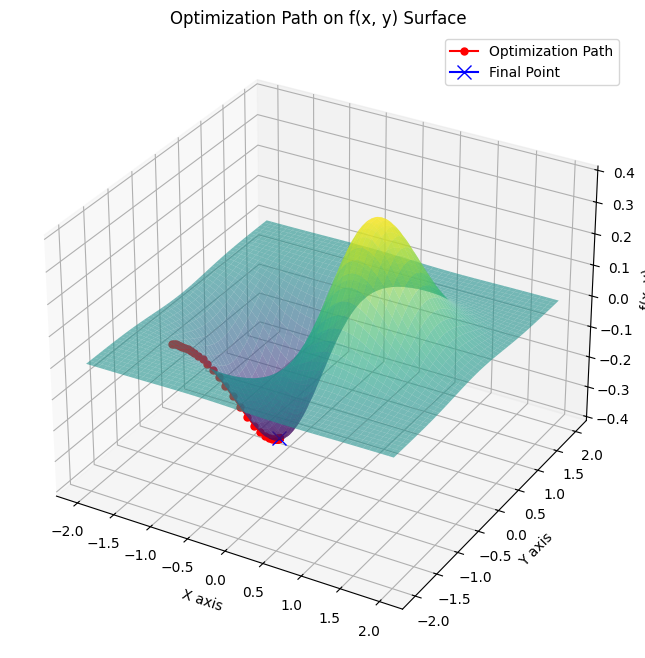

In [16]:
x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
x, y = np.meshgrid(x, y)
z = ExpTrig().forward(x,y)

# Assuming you have lists `x_values` and `y_values` containing the optimization path
x_values = np.array(x_arr)
y_values = np.array(y_arr)
z_values = np.exp(-np.array(x_values)**2 - np.array(y_values)**2) * np.sin(x_values) * np.cos(y_values)

# Plot the optimization path on the surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, cmap='viridis', alpha=0.6)
ax.plot(x_values, y_values, z_values, marker='o', color='r', markersize=5, label='Optimization Path')
ax.plot(x_values[-1], y_values[-1], z_values[-1], marker='x', color='b', markersize=10, label='Final Point')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('f(x, y)')
ax.set_title('Optimization Path on f(x, y) Surface')
ax.legend()
plt.show()


---
**Task 7 (medium): Reflection💡**
Assess the proficiency of the of the gradient descent algorithm
1. Use gradient descent to find the minimum using the following starting points:


$$
x_{0}=1.5, y_{0}=1.5 
$$

$$
x_{0}=-1.5, y_{0}=-1.5
$$

$$
x_{0}=-1.0, y_{0}=1.3
$$

$$
x_{0}=1.2, y_{0}=-1.5
$$
2. In the cell below describe the main observations from these optimizations.
3. Explain why the optimization process sometimes fails to find the **global** minimum?
4. Use different learning rates (try 0.1, 0.5, 1.0) and discuss how they affect the results.
5. List two issues commonly encountered in gradient descent optimization and provide a potential solution for each problem:    - Describe each issue and explain why it poses a challenge.
    - Propose a potential solution to address each issue effectively.




---

## Task 7: Reflection on Gradient Descent

### 2. Main observations from optimizations with different starting points

**Observations:**

- **Convergence to different minima**: Different starting points lead to convergence at different local minima. The algorithm finds the nearest local minimum from each starting point, not necessarily the global minimum.

- **Path dependence**: The optimization path and final result depend heavily on the starting point. Starting points in different regions of the function landscape converge to different local minima.

- **Convergence speed varies**: Some starting points converge faster than others, depending on:
  - Distance to the nearest local minimum
  - Steepness of the gradient path
  - Presence of flat regions or plateaus

- **Oscillation patterns**: Some paths show more oscillation than others, particularly when:
  - Starting in regions with high curvature
  - The learning rate is not well-tuned for that region
  - The path crosses narrow valleys

- **Final function values differ**: Different starting points result in different final function values, indicating that the algorithm finds different local minima rather than the global minimum.

### 3. Why the optimization process sometimes fails to find the global minimum?

**Reasons for failure:**

- **Local minima trap**: Gradient descent is a greedy algorithm that always moves in the direction of steepest descent. Once it enters a local minimum's basin of attraction, it gets trapped there because the gradient becomes zero or very small, preventing escape to potentially better minima.

- **No global information**: The algorithm only uses local gradient information at each point. It has no knowledge of the global structure of the function, so it cannot "see" that a better minimum exists elsewhere.

- **Gradient-based limitation**: Since gradient descent only follows the negative gradient direction, it cannot escape local minima where gradients are zero or point toward the local minimum.

- **Multiple minima**: Functions like f(x,y) = e^(-x²-y²) * sin(x) * cos(y) have multiple local minima due to the oscillatory nature of sin and cos. The algorithm finds the nearest local minimum, not necessarily the global one.

- **Starting point dependency**: The choice of starting point determines which local minimum the algorithm will find. If the starting point is far from the global minimum, the algorithm may never reach it.

**Mathematical explanation:**
- At a local minimum, ∇f = 0, so the update rule x_new = x_old - learning_rate * ∇f results in no movement (or very small movement).
- The algorithm has no mechanism to "jump out" of local minima to explore other regions.

### 4. How different learning rates (0.1, 0.5, 1.0) affect the results

**Learning rate = 0.1 (small):**

- **Behavior**: Slow, stable convergence
- **Path**: Small steps, closely spaced points, smooth path
- **Convergence**: Takes many iterations to converge, but stable
- **Risk**: May get stuck in flat regions, very slow progress
- **Result**: More likely to converge to the nearest local minimum from starting point

**Learning rate = 0.5 (moderate):**

- **Behavior**: Balanced convergence speed and stability
- **Path**: Moderate step sizes, reasonable convergence speed
- **Convergence**: Faster than 0.1, but may show some oscillation in high-curvature regions
- **Risk**: May overshoot in steep regions, causing some oscillation
- **Result**: Good balance between speed and stability

**Learning rate = 1.0 (large):**

- **Behavior**: Fast but potentially unstable
- **Path**: Large steps, may overshoot, oscillate, or diverge
- **Convergence**: May converge quickly if stable, but risk of:
  - Overshooting the minimum and oscillating
  - Diverging if the function is very steep
  - Jumping over local minima (which could be good or bad)
- **Risk**: High risk of instability, oscillation, or divergence
- **Result**: May find different minima due to large steps, or may fail to converge

**Key insights:**
- **Too small**: Slow but safe - guaranteed convergence if function is convex
- **Too large**: Fast but risky - may oscillate or diverge
- **Optimal**: Depends on the function's local geometry - may need adaptive learning rates

### 5. Two issues commonly encountered in gradient descent optimization and solutions

**Issue 1: Getting stuck in local minima**

**Description**: Gradient descent can converge to a local minimum that is not the global minimum. This occurs because the algorithm only follows the local gradient, which becomes zero at any minimum (local or global). Once trapped, the algorithm cannot escape because there's no gradient to follow.

**Why it's a challenge**: 
- The algorithm has no way to distinguish between local and global minima
- The final solution depends on the starting point, making results non-deterministic
- For non-convex functions (like the ExpTrig function), multiple local minima exist

**Potential solutions**:
- **Multiple random restarts**: Run gradient descent from many different starting points and choose the best result. This increases the probability of finding the global minimum.
- **Simulated annealing**: Add randomness to the algorithm, allowing it to occasionally accept moves that increase the function value, enabling escape from local minima.
- **Momentum methods**: Use momentum to help the algorithm "roll over" small local minima by maintaining velocity from previous steps.
- **Adaptive learning rates**: Use methods like Adam or AdaGrad that adapt the learning rate, potentially helping escape shallow local minima.

**Issue 2: Slow convergence in flat regions (plateaus)**

**Description**: In regions where the gradient is very small (flat regions or plateaus), gradient descent makes extremely small steps, leading to very slow progress. The algorithm may take many iterations to traverse these regions or may appear to stagnate.

**Why it's a challenge**:
- The step size is proportional to the gradient magnitude: step = learning_rate × gradient
- When gradients are near zero, steps become tiny, even with a reasonable learning rate
- The algorithm may require thousands of iterations to cross a flat region
- May get stuck in saddle points (points where gradient is zero but not a minimum)

**Potential solutions**:
- **Adaptive learning rates**: Use methods like AdaGrad or RMSprop that increase the effective learning rate in flat regions by accumulating gradient information.
- **Momentum**: Momentum helps maintain movement through flat regions by carrying forward velocity from previous steps, even when current gradients are small.
- **Second-order methods**: Use methods like Newton's method or quasi-Newton methods (BFGS) that use second-order information (Hessian) to make larger steps in flat regions.
- **Learning rate scheduling**: Gradually increase the learning rate when progress is slow, or use techniques like learning rate warmup.

**Additional common issues (for reference)**:

**Issue 3: Oscillation around minima**
- **Solution**: Reduce learning rate, use momentum, or implement learning rate decay

**Issue 4: Divergence with large learning rates**
- **Solution**: Use learning rate scheduling, gradient clipping, or adaptive learning rates

**Issue 5: Sensitivity to initialization**
- **Solution**: Use multiple random restarts, smart initialization strategies (Xavier/He initialization for neural networks), or pre-training

In [0]:
# Write your reflections here...